# AI Workshop for Business & Finance Faculty at ODU
## From Traditional AI to Modern LLMs: A Hands-On Journey

---

### Workshop Outline

1. **Introduction to Google Colab**
   - What is Colab and why use it?
   - Setting up your environment
   - Basic operations & GPU access

2. **Traditional Machine Learning in Business**
   - The evolution of AI: from symbolic to deep learning
   - Hands-on SVM example: Credit Risk Classification

3. **Hands-On: Neural Network for Business**
   - Customer Churn Prediction using deep learning
   - Building, training, and evaluating a neural network

4. **Practical Applications & Next Steps**
   - ODU Monarch Sphere: AI tools and resources
   - From neural networks to Large Language Models (LLMs)
   - Business applications and prompting strategies


---
# Part 1: Introduction to Google Colab
---

## 1.1 What is Google Colab?

**Colab** (Colaboratory) is a free cloud service that allows you to:
- Write and execute Python code in your browser
- Access GPUs and TPUs for free (for computational tasks)
- Share notebooks easily with colleagues
- No installation or setup required

### Key Features for Business Applications:
- **Zero setup**: No need to install Python or libraries
- **Collaboration**: Share notebooks like Google Docs
- **Free computing power**: Access to powerful machines
- **Integration**: Works with Google Drive, GitHub

## 1.2 Basic Python Commands in Colab

Colab uses **cells** - blocks of code or text. Let's try some basic commands:

In [ ]:
# Check Python version
!python --version

In [ ]:
# Simple Python calculation
revenue = 1000000
growth_rate = 0.15
projected_revenue = revenue * (1 + growth_rate)

print(f"Current Revenue: ${revenue:,}")
print(f"Growth Rate: {growth_rate*100}%")
print(f"Projected Revenue: ${projected_revenue:,}")

## 1.3 Checking Available Resources

Colab provides free GPU access. Let's check what's available:

In [ ]:
# Check if GPU is available
import torch

if torch.cuda.is_available():
    print(f"✓ GPU is available: {torch.cuda.get_device_name(0)}")
    print(f"  Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("✗ No GPU available. Using CPU.")
    print("  To enable GPU: Runtime → Change runtime type → GPU")

## 1.4 Working with Files

You can access files in multiple ways:

In [ ]:
# Optional: Mount Google Drive to access your files
# Uncomment the lines below to use:

# from google.colab import drive
# drive.mount('/content/drive')
# print("✓ Google Drive mounted successfully!")

---
# Part 2: Traditional Machine Learning in Business
---

<!-- ## 2.1 The Evolution of AI

### 📋 **Era 1: Symbolic AI (1950s-1980s)**
**Approach**: Rule-based systems with explicit programming

**Example in Business**:
```
IF customer_purchase > $1000 AND loyalty_years > 5
   THEN offer_discount = 20%
ELSE IF customer_purchase > $500
   THEN offer_discount = 10%
```

**Limitations**: Required manual rule creation, couldn't handle ambiguity, difficult to scale

---

### 📊 **Era 2: Machine Learning (1990s-2010s)**
**Approach**: Systems learn patterns from data

**Examples**: Credit scoring, fraud detection, customer churn prediction

**Advantage**: No need to manually write rules - let data speak

---

### 🧠 **Era 3: Deep Learning (2010s-present)**
**Approach**: Neural networks with multiple layers

**Examples**: Image recognition, natural language processing, autonomous systems

**Advantage**: Learns hierarchical patterns automatically

---

### 🚀 **Era 4: Large Language Models (2020s-present)**
**Approach**: Massive neural networks trained on trillions of words

**Examples**: ChatGPT, Claude, Gemini

**Advantage**: General-purpose AI - solve many tasks with natural language -->

## 2.1 Hands-On: Traditional ML Example - Credit Risk Classification with SVM

Let's build a **Support Vector Machine (SVM)** model to predict whether a customer is a credit risk.

### The Problem: Credit Risk Assessment

Banks need to decide: **Should we approve this loan?**

**Features we'll use:**
- Income level
- Years of credit history
- Previous loan defaults
- Monthly debt payments

**Target**: Predict if customer will default (1 = High Risk, 0 = Low Risk)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
# Create synthetic credit dataset
n_samples = 200

income = np.random.uniform(20000, 150000, n_samples)
credit_history = np.random.uniform(1, 30, n_samples)
debt_payments = np.random.uniform(100, 5000, n_samples)
previous_defaults = np.random.binomial(n=1, p=0.3, size=n_samples)

# Target: Higher risk if low income, short credit history, high debt, previous defaults
risk_score = (200000 - income) / 100000 + (10 - credit_history) / 5 + debt_payments / 2500 + previous_defaults * 2
default = (risk_score > 1.5).astype(int)

df = pd.DataFrame({
    'Income': income,
    'CreditHistory': credit_history,
    'MonthlyDebt': debt_payments,
    'PreviousDefaults': previous_defaults,
    'Default': default
})

print("📊 Dataset Shape:", df.shape)
print("\n📈 First few records:")
print(df.head())
print(f"\n⚠️  Default Rate: {df['Default'].mean()*100:.1f}% of customers")

📊 Dataset Shape: (200, 5)

📈 First few records:
          Income  CreditHistory  MonthlyDebt  PreviousDefaults  Default
0   68690.215450      19.618918   605.306957                 0        0
1  143592.859833       3.440059  4522.509243                 0        1
2  115159.212435       5.687233  2575.736625                 0        1
3   97825.602946      27.058071  4149.641584                 0        0
4   40282.423258      18.586443  1668.243045                 0        0

⚠️  Default Rate: 49.0% of customers


In [3]:
# Prepare data
X = df.drop('Default', axis=1)
y = df['Default']

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for SVM!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 160 samples
Testing set size: 40 samples
Number of features: 4


In [4]:
# Train SVM model
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("✓ SVM Model trained successfully!")
print(f"Number of support vectors: {len(svm_model.support_vectors_)}")

✓ SVM Model trained successfully!
Number of support vectors: 61


In [5]:
# Make predictions and evaluate
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Model Accuracy: {accuracy*100:.1f}%")
print(f"Correct predictions: {(y_pred == y_test).sum()} out of {len(y_test)}")
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(
    y_test, y_pred,
    target_names=['Low Risk', 'High Risk']
))

🎯 Model Accuracy: 100.0%
Correct predictions: 40 out of 40

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00        20
   High Risk       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



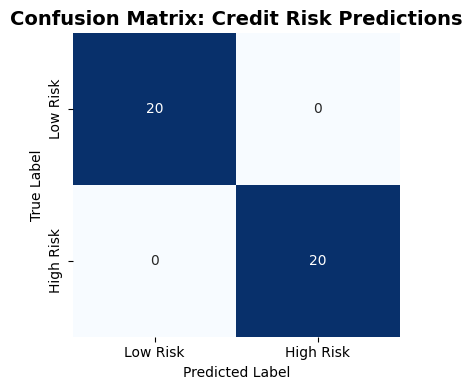

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Confusion Matrix: Credit Risk Predictions', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

---
# Part 3: Hands-On Neural Network for Business
---

## 3.1 The Business Problem: Customer Churn Prediction

**Churn** = Customer leaving/canceling subscription

### Business Impact:
- 5% churn rate means 5 out of 100 customers leave each month
- Retaining customers is 5-25x cheaper than acquiring new ones
- **Predicting churn** lets us take action (discounts, outreach) before customers leave

### Our Approach:
Build a **Neural Network** to predict customer churn using:
- Contract length, monthly charges, internet speed
- Customer age, service quality metrics
- **Target**: Will customer churn? (Yes/No)

## 3.2 Environment Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("✓ All libraries imported!")
print(f"PyTorch version: {torch.__version__}")

✓ All libraries imported!
PyTorch version: 2.10.0+cu128


## 3.3 Creating Customer Data

In [11]:
# Create synthetic customer churn dataset
np.random.seed(42)
n_customers = 1000

# Generate customer features
data = {
    'ContractLength': np.random.choice([1, 2, 3], n_customers),  # Months
    'MonthlyCharges': np.random.uniform(20, 120, n_customers),
    'TotalCharges': np.random.uniform(100, 8000, n_customers),
    'CustomerAge': np.random.uniform(18, 80, n_customers),
    'InternetSpeed': np.random.uniform(1, 100, n_customers),
    'CustomerServiceCalls': np.random.randint(0, 9, n_customers)
}

# Create churn target (probability based on customer attributes)
churn_prob = (
    (4 - data['ContractLength']) * 0.1 +
    data['MonthlyCharges'] / 150 * 0.2 +
    data['CustomerServiceCalls'] * 0.05
)
churn_prob = np.clip(churn_prob, 0, 1)
data['Churn'] = np.random.binomial(1, churn_prob)

df = pd.DataFrame(data)

print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")
print(f"\nFirst few customers:")
print(df.head())

Dataset shape: (1000, 7)
Churn rate: 48.0%

First few customers:
   ContractLength  MonthlyCharges  TotalCharges  CustomerAge  InternetSpeed  \
0               3       28.023375   6957.647852    62.218827      72.735230   
1               1       72.451139   6466.810661    30.351347      12.047707   
2               3       61.039683   6341.240447    73.193330      61.223631   
3               3      118.237862   2506.965199    35.819395      28.823925   
4               1       31.203890    739.262336    40.802731      18.176109   

   CustomerServiceCalls  Churn  
0                     7      1  
1                     3      1  
2                     6      0  
3                     1      0  
4                     1      1  


## 3.4 Data Preparation

In [12]:
# Prepare data
X = df.drop('Churn', axis=1).values
y = df['Churn'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Input features: {X_train.shape[1]}")

Training samples: 800
Testing samples: 200
Input features: 6


## 3.5 Building the Neural Network

We'll create a **Multi-Layer Perceptron** with:
- **Input**: 6 customer features
- **Hidden layers**: 64 → 32 → 16 neurons (decreasing size)
- **Output**: 2 classes (Churn / No Churn)
- **Activation**: ReLU (learns non-linear patterns)
- **Dropout**: Prevents overfitting (0.2-0.3)

In [13]:
class ChurnPredictorNN(nn.Module):
    def __init__(self, input_size=6, hidden_sizes=[64, 32, 16]):
        super(ChurnPredictorNN, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.dropout3 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(hidden_sizes[2], 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)

        x = self.relu(self.fc2(x))
        x = self.dropout2(x)

        x = self.relu(self.fc3(x))
        x = self.dropout3(x)

        x = self.fc4(x)
        return x

# Create model
model = ChurnPredictorNN(input_size=6, hidden_sizes=[64, 32, 16])
print("Model Architecture:")
print(model)

Model Architecture:
ChurnPredictorNN(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
)


## 3.6 Training Setup

We need to define:
- **Loss function**: CrossEntropyLoss (for classification)
- **Optimizer**: Adam (adjusts weights automatically)
- **Learning rate**: How much to adjust per step (0.001)

In [14]:
# Loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 50

print("✓ Training configuration ready:")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: Adam")
print(f"  Learning rate: 0.001")
print(f"  Epochs: {epochs}")

✓ Training configuration ready:
  Loss function: CrossEntropyLoss
  Optimizer: Adam
  Learning rate: 0.001
  Epochs: 50


## 3.7 Training the Model

Now we'll train! Each epoch:
1. Show examples to model
2. Make predictions
3. Calculate loss (how wrong we are)
4. Adjust weights to reduce loss
5. Repeat!

In [15]:
# Training loop
train_losses = []

for epoch in range(epochs):
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = loss_function(outputs, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

print("\n✓ Training complete!")

Epoch 10/50 - Loss: 0.6467
Epoch 20/50 - Loss: 0.6348
Epoch 30/50 - Loss: 0.6427
Epoch 40/50 - Loss: 0.6127
Epoch 50/50 - Loss: 0.6029

✓ Training complete!


## 3.8 Visualizing Training Progress

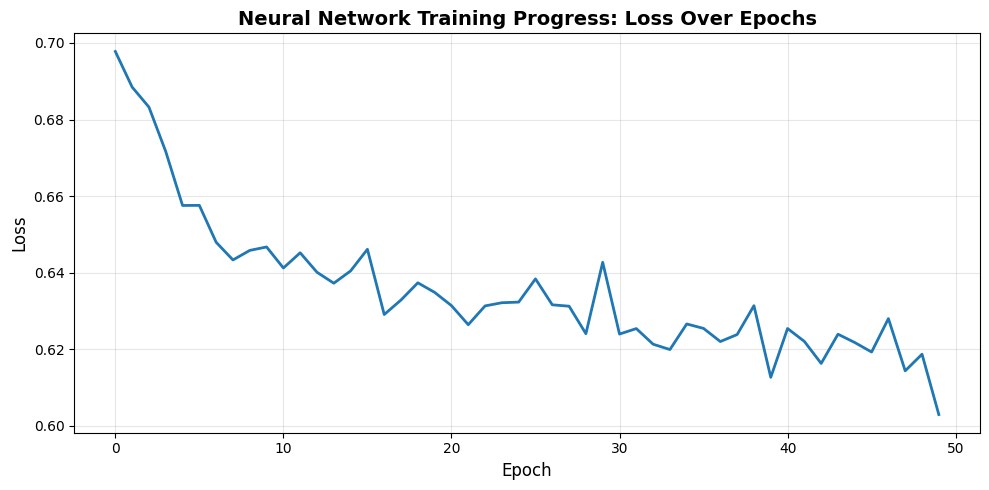

Initial Loss: 0.6978
Final Loss: 0.6029
Improvement: 13.6%


In [16]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, linewidth=2, color='#1f77b4')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Neural Network Training Progress: Loss Over Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial Loss: {train_losses[0]:.4f}")
print(f"Final Loss: {train_losses[-1]:.4f}")
print(f"Improvement: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.1f}%")

## 3.9 Evaluating Model Performance

In [17]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_predictions = torch.argmax(test_outputs, dim=1).numpy()

accuracy = (test_predictions == y_test).mean()
print(f"🎯 Test Accuracy: {accuracy*100:.1f}%")
print(f"\nCorrect predictions: {(test_predictions == y_test).sum()} out of {len(y_test)}")
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(
    y_test, test_predictions,
    target_names=['No Churn', 'Churn']
))

🎯 Test Accuracy: 65.0%

Correct predictions: 130 out of 200

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.64      0.73      0.68       104
       Churn       0.66      0.56      0.61        96

    accuracy                           0.65       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.65      0.65      0.65       200



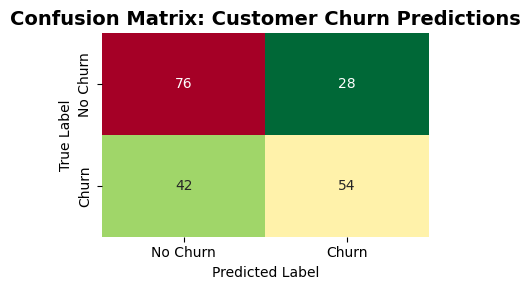

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', cbar=False,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix: Customer Churn Predictions', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 3.10 Making Predictions on New Customers

In [20]:
# Make predictions on a few test examples
model.eval()
sample_indices = np.random.choice(len(X_test), 5, replace=False)

print("Sample Predictions:")
print("="*60)

for idx, i in enumerate(sample_indices):
    with torch.no_grad():
        input_tensor = X_test_tensor[i:i+1]
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)[0].numpy()
        predicted_class = torch.argmax(output, dim=1).item()

    actual = y_test[i]
    churn_prob = probabilities[1]
    prediction = "Churn" if predicted_class == 1 else "No Churn"
    actual_label = "Churn" if actual == 1 else "No Churn"

    print(f"\nCustomer {idx+1}:")
    print(f"  Actual: {actual_label}")
    print(f"  Predicted: {prediction}")
    print(f"  Churn Probability: {churn_prob:.2%}")

Sample Predictions:

Customer 1:
  Actual: Churn
  Predicted: Churn
  Churn Probability: 71.48%

Customer 2:
  Actual: No Churn
  Predicted: No Churn
  Churn Probability: 41.07%

Customer 3:
  Actual: Churn
  Predicted: No Churn
  Churn Probability: 39.34%

Customer 4:
  Actual: No Churn
  Predicted: No Churn
  Churn Probability: 41.78%

Customer 5:
  Actual: Churn
  Predicted: No Churn
  Churn Probability: 44.97%


---
# Part 4: Practical Applications & Next Steps
---


LLM Prompting Guide:
https://github.com/rochanaro/ai-workshop-2026/blob/main/LLM_Prompting_Guide_Business_Faculty.md

## 4.1 ODU Monarch Sphere: AI Innovation and Incubation

### What is the Monarch Sphere?

Old Dominion University and Google have launched a **first-of-its-kind AI Incubator** designed to empower faculty and students with advanced AI tools and resources.

**Link**: https://www.odu.edu/forward-focused-transformation/monarchsphere

---

### 🎯 Key Components

#### 1. **Access to Advanced AI Tools**
- **Gemini**: Google's powerful multimodal AI (text, images, code analysis)
- **NotebookLM**: AI-powered notebook tool for research and analysis
- **Vertex AI**: Enterprise-grade machine learning platform
- **Agent Builder**: Create custom AI agents without coding

#### 2. **Research Use of Google Cloud Platform (GCP)**
- Free or subsidized cloud computing for research projects
- Scalable infrastructure for training large models
- Data storage and processing capabilities
- Integration with academic research workflows

#### 3. **AI Innovation & Pilot Projects**
- **Internal Incubator**: Support for faculty-led AI projects
- Proof-of-concept funding for business and educational applications
- Mentorship from Google and ODU AI experts
- Opportunity to pilot AI solutions before broader deployment

---

### 💡 How This Benefits Your Teaching

As faculty, you can:
1. **Leverage Gemini** for student projects and research
2. **Use Vertex AI** to teach ML with enterprise tools
3. **Build AI Agents** for business case studies
4. **Access GCP** for computational research
5. **Participate in pilots** to test AI innovations in curriculum

## 4.2 From Neural Networks to Large Language Models

The neural network we just built is **specialized** - it only predicts churn.

**Large Language Models (LLMs)** like ChatGPT, Claude, and Gemini are:
- Built on the same fundamental neural network principles
- But **much larger** (billions of parameters vs. our ~100,000)
- Trained on **massive text datasets** (books, websites, articles)
- **General-purpose** - can handle many different tasks

### Key Differences:

| Aspect | Our Network | Large Language Models |
|--------|---------|----------------------|
| Parameters | ~100,000 | Billions (100M - 1T+) |
| Training Data | 1,000 records | Trillions of words |
| Task | Churn prediction | General text tasks |
| Training Time | Minutes | Weeks/Months |
| Training Cost | Free | Millions of dollars |
| Capabilities | One task | Versatile reasoning |

### But the Core Idea is the Same:
1. **Input**: Data (customer features → text)
2. **Processing**: Multiple layers of neural networks
3. **Learning**: Adjust weights based on errors
4. **Output**: Predictions (churn → next word/answer)

## 4.3 Why LLMs are Transformative for Business

### Traditional ML Approach:
- Build specific model for each task
- Requires labeled training data
- Needs ML expertise
- Long development time

### LLM Approach:
- One model for many tasks
- Use natural language prompts
- No ML expertise needed
- Immediate deployment

### Business Impact Example:

**Before LLMs**: To classify customer emails by urgency:
1. Hire ML engineer → 2. Collect labeled data → 3. Train model → 4. Deploy
5. **Timeline**: 3-6 months

**With LLMs**: Same task:
1. Write a prompt: "Classify this email as urgent/normal/low priority"
2. **Timeline**: 5 minutes


## 4.4 LLM Use Cases for Faculty

### 📚 **Teaching & Learning**
- Generate discussion questions for your courses
- Create case studies and business scenarios
- Draft syllabus and course materials
- Explain complex topics in multiple ways

### 📊 **Research & Analysis**
- Analyze qualitative data and interviews
- Summarize research papers
- Generate literature review outlines
- Interpret statistical results in plain language

### 💼 **Business Analysis**
- Analyze financial documents (10-K filings, annual reports)
- Create SWOT analyses and strategic plans
- Draft business proposals and memos
- Conduct competitive intelligence

### ✍️ **Content Creation**
- Draft emails, memos, and reports
- Create quiz and test questions
- Generate marketing materials
- Write professional communications

---

**Next Steps**: See the **[LLM Prompting Guide](https://github.com/rochanaro/ai-workshop-2026/blob/main/LLM_Prompting_Guide_Business_Faculty.md)** for:
- Detailed prompting techniques
- Business-specific examples
- Finance and accounting use cases
- Productivity automation ideas

---
## 🎯 Workshop Summary

**What We Covered:**

✅ **Google Colab**: Free cloud computing for AI/ML

✅ **Traditional ML**: SVM for credit risk classification

✅ **Deep Learning**: Neural network for customer churn prediction
  - Built and trained a 4-layer MLP
  - Visualized training progress
  - Achieved meaningful accuracy on business problem

✅ **Real-World Applications**: Same principles apply across industries

✅ **ODU Resources**: Access to advanced AI tools through Monarch Sphere

✅ **LLMs**: Extend neural network principles to general-purpose AI

<br>

**Key Takeaway**:
AI isn't magic - it's mathematics and statistics at scale. Understanding the fundamentals helps you use modern tools like LLMs more effectively in your context.

<br>

---

<br>

**Instructor**: [Rochana R. Obadage](https://rochanaro.github.io/)  
**Last Updated**: April 17, 2026
